In [1]:
# Clone the repository
!git clone --depth 2 --single-branch --branch dev https://github.com/UniversalDependencies/UD_English-EWT.git

Cloning into 'UD_English-EWT'...
remote: Enumerating objects: 1217, done.
remote: Counting objects: 100% (1217/1217), done.
remote: Compressing objects: 100% (1141/1141), done.
remote: Total 1217 (delta 492), reused 338 (delta 74), pack-reused 0
Receiving objects: 100% (1217/1217), 6.96 MiB | 4.86 MiB/s, done.
Resolving deltas: 100% (492/492), done.


In [2]:
!pip install conllu
import conllu
import pandas as pd
import numpy as np



def read_conllu_file(file_path):
    """
    Read a conllu file and read each sentences separated
    :param file_path: String
    :return: data in sentences specifically: <class 'conllu.models.SentenceList'>
    """
    # Read the CoNLL-U file
    with open(file_path, "r", encoding="utf-8") as f:
        # Parse the CoNLL-U formatted data
        data = f.read()
        sentences = conllu.parse(data)
    return sentences


# Function to extract tokens and UPOS tags from
# SentenceList object and create a DataFrame
def create_pos_df(sentences):
    """
    Read the conllu sentences list and import them in a dataframe
    including the information we need
    :param sentences: conllu.models.SentenceList
    :return: pd.DataFrame object
    """
    id_list = []
    tokens_list = []
    upos_tags_list = []

    for sentence in sentences:
        for token in sentence:  # Extract token and UPOS tag
            id = token['id']
            token_text = token['form']
            upos_tag = token['upos']

            id_list.append(id)
            tokens_list.append(token_text)
            upos_tags_list.append(upos_tag)


    # Create dataframe
    dataframe = pd.DataFrame({'id': id_list, "token": tokens_list, "UPOS": upos_tags_list})
    return dataframe

# Initialize the file paths
for split in ('train', 'dev', 'test'):
    file_path = f'UD_English-EWT/en_ewt-ud-{split}.conllu'
    print(file_path)
    sentences = read_conllu_file(file_path)

    # Create DataFrame for the current split
    pos_df = create_pos_df(sentences)
    # Assign DataFrame to variable with specific name
    globals()[f"{split}_pos"] = pos_df

UD_English-EWT/en_ewt-ud-train.conllu
UD_English-EWT/en_ewt-ud-dev.conllu
UD_English-EWT/en_ewt-ud-test.conllu


In [3]:
print(f"train_pos dataframe: {len(train_pos)}")
print(f"test_pos dataframe: {len(test_pos)}")
print(f"dev_pos dataframe: {len(dev_pos)}")

!rm -rf /content/UD_English-EWT # free up memory

train_pos dataframe: 207229
test_pos dataframe: 25450
dev_pos dataframe: 25511


In [4]:
# Check the labels of our data
train_pos.UPOS.unique()

array(['PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'DET', 'ADP', 'AUX',
       'PRON', 'PART', 'SCONJ', 'NUM', 'ADV', 'CCONJ', '_', 'INTJ', 'X',
       'SYM'], dtype=object)

In [5]:
# Drop rows that contain UPOS = '_'
train_pos = train_pos[train_pos.UPOS != '_']
test_pos = test_pos[test_pos.UPOS != '_']
dev_pos = dev_pos[dev_pos.UPOS != '_']

In [6]:
print("Number of tags: ",len(train_pos.UPOS.unique()))

Number of tags:  17


In [7]:
print(f'The length of the training set before the preprocess: {len(train_pos)}')

train_pos = train_pos[train_pos.id.apply(lambda x: isinstance(x, int))]
dev_pos = dev_pos[dev_pos.id.apply(lambda x: isinstance(x, int))]
test_pos = test_pos[test_pos.id.apply(lambda x: isinstance(x, int))]

# Reset the index of our dataframes because we dropped some rows
train_pos = train_pos.reset_index()
dev_pos = dev_pos.reset_index()
test_pos = test_pos.reset_index()

print(f'After the preprocess: {len(train_pos)}')

The length of the training set before the preprocess: 204615
After the preprocess: 204578


In [8]:
train_pos.head(35)

,index,id,token,UPOS
0,0,1,Al,PROPN
1,1,2,-,PUNCT
2,2,3,Zaman,PROPN
3,3,4,:,PUNCT
4,4,5,American,ADJ
5,5,6,forces,NOUN
6,6,7,killed,VERB
7,7,8,Shaikh,PROPN
8,8,9,Abdullah,PROPN
9,9,10,al,PROPN


In [42]:
test_pos.UPOS.value_counts()

NOUN     4137
PUNCT    3096
VERB     2605
PRON     2161
PROPN    2077
ADP      2033
DET      1897
ADJ      1787
AUX      1543
ADV      1178
CCONJ     737
PART      649
NUM       542
SCONJ     384
INTJ      120
SYM       109
X          39
Name: UPOS, dtype: int64

Now lets build our dataset in sentences.

In [9]:
from tqdm import tqdm


def make_sentences(dataframe):
    """
    Make sentences from the train, development and test set in order
    to create windows for each word
    :param dataframe: pandas df
    :return: array of sentences
    :return: array of position of each word
    :return: array of tags for each word
    """
    all_sents = []
    all_positions = []
    all_tags = []
    sentence = []
    position = []
    pos_tags = []
    cnt = 0
    with tqdm(total = len(dataframe)) as pbar:
        for index, row in dataframe.iterrows():
            id = row['id']
            token= row['token']
            upos = row['UPOS']
            if id > cnt:
                cnt = id
                sentence.append(token)
                position.append(index)
                pos_tags.append(upos)
            else:
                all_sents.append(sentence)
                all_positions.append(position)
                all_tags.append(pos_tags)
                sentence = []
                sentence.append(token)
                position= []
                position.append(index)
                pos_tags = []
                pos_tags.append(upos)
                cnt=id
            pbar.update(1)  # Update the progress bar
        all_sents.append(sentence)
        all_positions.append(position)
        all_tags.append(pos_tags)

    return all_sents, all_positions, all_tags

X_train, all_train_positions, y_train = make_sentences(train_pos)
print(f'\nThe total sentences of the training set is: {len(X_train)}')
X_dev, all_dev_positions, y_dev = make_sentences(dev_pos)
print(f'\nThe total sentences of the development set is: {len(X_dev)}')
X_test, all_test_positions, y_test = make_sentences(test_pos)
print(f'\nThe total sentences of the test set is: {len(X_test)}')

100%|██████████| 204578/204578 [00:38<00:00, 5343.24it/s]



The total sentences of the training set is: 12544


100%|██████████| 25149/25149 [00:04<00:00, 6225.97it/s]



The total sentences of the development set is: 2001


100%|██████████| 25094/25094 [00:04<00:00, 5583.31it/s]


The total sentences of the test set is: 2077


In [10]:
print("Size of train: ",len(X_train))
print("Size of dev: ",len(X_dev))
print("Size of test: ",len(X_test))

Size of train:  12544
Size of dev:  2001
Size of test:  2077


TOKENIZATION



In [11]:
# ΤΟΚΕΝΙΖΕ
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

In [12]:
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)
x_train_encoded = word_tokenizer.texts_to_sequences(X_train)
x_dev_encoded = word_tokenizer.texts_to_sequences(X_dev)
x_test_encoded = word_tokenizer.texts_to_sequences(X_test)

In [13]:
x_train_encoded[3]

[134, 7, 71, 62, 148, 406, 43, 143, 696, 7, 1, 4827, 7, 1, 8872, 50]

In [14]:
tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(y_train)
y_train_encoded = tag_tokenizer.texts_to_sequences(y_train)
y_dev_encoded = tag_tokenizer.texts_to_sequences(y_dev)
y_test_encoded = tag_tokenizer.texts_to_sequences(y_test)

In [15]:
y_train_encoded[3]

[13, 5, 4, 8, 8, 3, 5, 13, 1, 5, 6, 9, 5, 6, 9, 2]

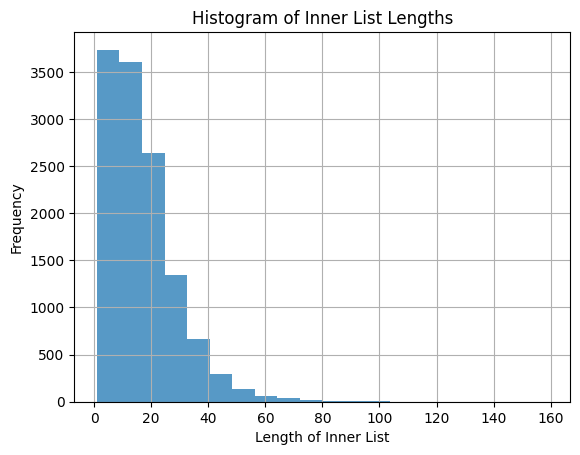

In [16]:
import matplotlib.pyplot as plt

# Get lengths of inner lists
lengths = [len(lst) for lst in x_train_encoded]

# Plotting histogram
plt.hist(lengths, bins=20, alpha=0.75)
plt.xlabel('Length of Sentence')
plt.ylabel('Frequency')
plt.title('Histogram of Sentences Length.')
plt.grid(True)
plt.show()

In [17]:
MAX_SEQ_LENGTH = 80

x_train_padded = pad_sequences(x_train_encoded, maxlen=MAX_SEQ_LENGTH, padding='pre',truncating='post')
y_train_padded = pad_sequences(y_train_encoded, maxlen=MAX_SEQ_LENGTH, padding='pre',truncating='post')

x_dev_padded = pad_sequences(x_dev_encoded, maxlen=MAX_SEQ_LENGTH, padding='pre',truncating='post')
y_dev_padded = pad_sequences(y_dev_encoded, maxlen=MAX_SEQ_LENGTH, padding='pre',truncating='post')

x_test_padded = pad_sequences(x_test_encoded, maxlen=MAX_SEQ_LENGTH, padding='pre',truncating='post')
y_test_padded = pad_sequences(y_test_encoded, maxlen=MAX_SEQ_LENGTH, padding='pre',truncating='post')

In [18]:
from pprint import pprint
pprint(x_train_padded[2])
pprint(y_train_padded[2])

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0, 8870,   47,  533,
       1655, 1944,   12,   24,   54, 8871,   64,  166, 1066, 3363, 1357,
          9, 1786,    2], dtype=int32)
array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  9,  2,  7,  1,  3,
       14,  4,  8,  3,  5, 13,  7,  1,  3,  5,  9,  2], dtype=int32)


In [19]:
from google.colab import drive
drive.mount('/content/drive')

from gensim.models import KeyedVectors

# Path to the Word2Vec model file in Google Drive
model_path = '/content/drive/My Drive/word2vec/GoogleNews-vectors-negative300.bin.gz'


# Load the Word2Vec model
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

embedding = word2vec_model['example']
print("Embedding length is: ",len(embedding))

Mounted at /content/drive
Embedding length is:  300


In [20]:
EMBEDDING_SIZE = 300
VOCAB_SIZE = len(word_tokenizer.word_index)+1

# create a weight matrix for words in training docs
embedding_matrix = np.zeros((VOCAB_SIZE , EMBEDDING_SIZE))

for word, i in word_tokenizer.word_index.items():
    try:
      embedding_matrix[i,:] = word2vec_model[word]
    except KeyError:
      pass

In [21]:
# Making y categorical
y_train_cat = to_categorical(y_train_padded)
y_dev_cat = to_categorical(y_dev_padded)
y_test_cat = to_categorical(y_test_padded)

In [22]:
y_train_cat.shape

(12544, 80, 18)

In [23]:
# Total number of tags
NUM_CLASSES = y_train_cat.shape[2]
print(NUM_CLASSES)

18


In [99]:
from sklearn.metrics import f1_score, recall_score, precision_score
import tensorflow as tf
import os


class Metrics(tf.keras.callbacks.Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Take only the non zero
        val_targ = self.validation_data[1]
        length = 0
        for i in range(80):
          if (val_targ[i] ==0):
            length = i
            break
        val_predict = np.argmax(self.model.predict(self.validation_data[0]), -1)
        val_predict = val_predict[-length]
        val_targ = val_targ[-length]
        val_targ = tf.cast(val_targ,dtype=tf.float32)
        if len(val_targ.shape) == 2 and val_targ.shape[1] != 1:
          val_targ = np.argmax(val_targ, -1)


        _val_f1 = f1_score(val_targ, val_predict,average="weighted")
        _val_recall = recall_score(val_targ, val_predict,average="weighted")
        _val_precision = precision_score(val_targ, val_predict,average="weighted")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %f — val_precision: %f — val_recall: %f" % (_val_f1, _val_precision, _val_recall))
        return

In [97]:
y_dev_cat[1].shape

(80, 18)

In [108]:
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, TimeDistributed, Dense, Dropout
from keras.optimizers import Adam
from keras.metrics import CategoricalAccuracy

bidirect_model = Sequential()
bidirect_model.add(Embedding(input_dim     = VOCAB_SIZE,
                             output_dim    = EMBEDDING_SIZE,
                             input_length  = MAX_SEQ_LENGTH,
                             weights       = [embedding_matrix],
                            #  mask_zero     = True,
                             trainable     = False
))
bidirect_model.add(Bidirectional(LSTM(80, return_sequences=True)))
# bidirect_model.add(Bidirectional(LSTM(80, return_sequences=True)))


# bidirect_model.add(TimeDistributed(Dense(75, activation='relu')))
bidirect_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))


bidirect_model.compile(loss='categorical_crossentropy',
              optimizer=Adam(0.00008),
              metrics=[CategoricalAccuracy()])

# check summary of model
bidirect_model.summary()


Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_11 (Embedding)    (None, 80, 300)           4996500   
                                                                 
 bidirectional_13 (Bidirect  (None, 80, 160)           243840    
 ional)                                                          
                                                                 
 time_distributed_11 (TimeD  (None, 80, 18)            2898      
 istributed)                                                     
                                                                 
Total params: 5243238 (20.00 MB)
Trainable params: 246738 (963.82 KB)
Non-trainable params: 4996500 (19.06 MB)
_________________________________________________________________


In [116]:
bidirect_training = bidirect_model.fit(x_train_padded, y_train_cat, batch_size=128, epochs=20, validation_data=(x_dev_padded, y_dev_cat))#,callbacks=[Metrics(valid_data=(np.array(x_dev_padded), y_dev_cat))])

Epoch 1/20
98/98 [==============================] - 46s 467ms/step - loss: 0.5132 - categorical_accuracy: 0.8505 - val_loss: 0.4342 - val_categorical_accuracy: 0.8795
Epoch 2/20
98/98 [==============================] - 41s 418ms/step - loss: 0.4864 - categorical_accuracy: 0.8603 - val_loss: 0.4195 - val_categorical_accuracy: 0.8830
Epoch 3/20
98/98 [==============================] - 43s 441ms/step - loss: 0.4628 - categorical_accuracy: 0.8703 - val_loss: 0.4043 - val_categorical_accuracy: 0.8891
Epoch 4/20
98/98 [==============================] - 41s 423ms/step - loss: 0.4400 - categorical_accuracy: 0.8809 - val_loss: 0.3927 - val_categorical_accuracy: 0.8920
Epoch 5/20
98/98 [==============================] - 42s 424ms/step - loss: 0.4182 - categorical_accuracy: 0.8920 - val_loss: 0.3820 - val_categorical_accuracy: 0.8962
Epoch 6/20
98/98 [==============================] - 43s 436ms/step - loss: 0.3968 - categorical_accuracy: 0.9019 - val_loss: 0.3726 - val_categorical_accuracy: 0.900

In [117]:
bidirect_model.evaluate(x_test_padded,y_test_cat)

65/65 [==============================] - 4s 69ms/step - loss: 0.3357 - categorical_accuracy: 0.9206


[0.3356856107711792, 0.920612633228302]

In [87]:
# preds = bidirect_model.predict(x_test_padded)

65/65 [==============================] - 9s 85ms/step


In [88]:
# np.argmax(preds[20][1])

In [89]:
# y_test_cat[100]

In [90]:
# preds[1][-5]

In [67]:
tag_tokenizer.word_index

{'noun': 1,
 'punct': 2,
 'verb': 3,
 'pron': 4,
 'adp': 5,
 'det': 6,
 'adj': 7,
 'aux': 8,
 'propn': 9,
 'adv': 10,
 'cconj': 11,
 'part': 12,
 'num': 13,
 'sconj': 14,
 'sym': 15,
 'intj': 16,
 'x': 17}

In [118]:
# Assuming tag_tokenizer.word_index is a dictionary mapping indices to class labels
class_labels = {idx: label for label, idx in tag_tokenizer.word_index.items()}

# # Add class '0' at the start of the dictionary
class_labels = {0: '0', **class_labels}


In [119]:
from sklearn.metrics import classification_report

# Assuming y_true contains the true labels and preds contains the predicted labels
# For example, if you have true labels stored in y_true and predicted labels stored in preds
predictions_test = np.argmax(bidirect_model.predict(x_test_padded), -1)
y_test = np.argmax(y_test_cat, -1)
# Flatten the arrays if they are not already flattened
y_true = y_test.flatten()
preds = predictions_test.flatten()

trues = []
test_preds = []
for i in range(len(y_true)):
  if y_true[i]>=0:
    trues.append(y_true[i])
    test_preds.append(preds[i])

# Generate the classification report
report = classification_report(trues, test_preds , target_names=class_labels.values())

# Print the report
print(report)


65/65 [==============================] - 5s 71ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    141067
        noun       0.59      0.58      0.59      4137
       punct       0.46      0.74      0.57      3095
        verb       0.53      0.52      0.53      2605
        pron       0.60      0.63      0.61      2161
         adp       0.45      0.41      0.43      2033
         det       0.46      0.38      0.42      1897
         adj       0.58      0.44      0.50      1787
         aux       0.58      0.57      0.57      1543
       propn       0.46      0.23      0.31      2077
         adv       0.45      0.49      0.47      1178
       cconj       0.52      0.02      0.04       737
        part       0.59      0.24      0.34       649
         num       0.59      0.06      0.10       542
       sconj       0.59      0.03      0.05       384
         sym       0.00      0.00      0.00       109
        intj       0.00    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [120]:
# Reshape the data to a 1D array
flattened_data = predictions_test.flatten()

# Use numpy's unique function to get unique values and their counts
unique_values, counts = np.unique(flattened_data, return_counts=True)

# Combine unique values and their counts into a dictionary
counts_dict = dict(zip(unique_values, counts))

print(counts_dict)


{0: 143357, 1: 4078, 2: 4951, 3: 2552, 4: 2263, 5: 1866, 6: 1559, 7: 1347, 8: 1506, 9: 1039, 10: 1281, 11: 33, 12: 260, 13: 51, 14: 17}
